# MLP 3x128 GELU + Dropout + L2

Arquitectura fija basada en el mejor resultado del notebook de busqueda de hiperparametros.

Config:

- 3 capas ocultas
- 128 neuronas por capa
- activacion GELU
- Dropout `0.05`
- L2 `1e-4`
- Adam con learning rate `1e-3`
- batch size `256`
- EarlyStopping con `restore_best_weights=True`

Entrena esta arquitectura para las 16 combinaciones de ventanas y guarda resultados en `data/mlp/`.

Este notebook registra cada celda del grid en MLflow igual que los notebooks `01` a `06`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "util.py").exists():
    for parent in Path.cwd().parents:
        if (parent / "util.py").exists():
            PROJECT_ROOT = parent
            break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import keras
from keras import regularizers
from keras.callbacks import EarlyStopping
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error

from util import (
    get_train_test,
    RANDOM_SEED,
    compare_to_benchmark,
    plot_benchmark_comparison,
    configure_mlflow,
    log_keras_grid_run,
)

keras.utils.set_random_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [2]:
MODEL_NAME = "mlp_3x128_gelu_dropout_l2"
EXPERIMENT_NAME = "MLP"
LOG_MODEL_ARTIFACT = False
ARCHITECTURE_PARAMS = {
    "hidden_layers": 3,
    "neurons": 128,
    "activation": "gelu",
    "regularization": "dropout_l2",
    "dropout_rate": 0.05,
    "l2": 1e-4,
    "batch_norm": False,
    "early_stopping": True,
    "patience": 20,
    "min_delta": 1e-6,
}

mlflow = configure_mlflow(EXPERIMENT_NAME)
RESULTS_PATH = PROJECT_ROOT / "data" / "mlp" / f"{MODEL_NAME}.csv"
HISTORY_PATH = PROJECT_ROOT / "data" / "mlp" / f"{MODEL_NAME}_history.csv"

input_windows = [5, 10, 30, 90]
output_windows = [1, 5, 30, 90]

EPOCHS = 500
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
VALIDATION_SPLIT = 0.1
PATIENCE = 20
MIN_DELTA = 1e-6

RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
print("results:", RESULTS_PATH)
print("history:", HISTORY_PATH)

results: /Users/jchulvi/projects/Neural-Networks-Forecasting/data/mlp/mlp_3x128_gelu_dropout_l2.csv
history: /Users/jchulvi/projects/Neural-Networks-Forecasting/data/mlp/mlp_3x128_gelu_dropout_l2_history.csv


## Definicion de la red

In [3]:
def build_model(input_dim, output_dim):
    l2_reg = regularizers.l2(1e-4)

    model = Sequential()
    model.add(Input(shape=(input_dim,)))
    model.add(Dense(128, activation="gelu", kernel_regularizer=l2_reg))
    model.add(Dropout(0.05))
    model.add(Dense(128, activation="gelu", kernel_regularizer=l2_reg))
    model.add(Dropout(0.05))
    model.add(Dense(128, activation="gelu", kernel_regularizer=l2_reg))
    model.add(Dropout(0.05))
    model.add(Dense(output_dim))
    model.compile(loss="mean_absolute_error", optimizer=Adam(learning_rate=LEARNING_RATE))
    return model


def make_early_stopping():
    return EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        min_delta=MIN_DELTA,
        restore_best_weights=True,
    )


## Entrenamiento en grid de ventanas

In [ ]:
results = []
history_rows = []

for in_w in input_windows:
    for out_w in output_windows:
        d = get_train_test(input_window_size=in_w, output_window_size=out_w)

        X_train = d.X_train.reshape(d.X_train.shape[0], -1)
        X_test = d.X_test.reshape(d.X_test.shape[0], -1)

        keras.utils.set_random_seed(RANDOM_SEED)
        model = build_model(input_dim=X_train.shape[1], output_dim=d.y_train.shape[1])

        hist = model.fit(
            X_train,
            d.y_train,
            validation_split=VALIDATION_SPLIT,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            # callbacks=[make_early_stopping()],
            verbose=0,
            shuffle=False,
        )

        y_pred_train = model.predict(X_train, verbose=0)
        y_pred_test = model.predict(X_test, verbose=0)

        val_losses = np.asarray(hist.history["val_loss"], dtype=float)
        row = {
            "model_name": MODEL_NAME,
            "input_window": in_w,
            "output_window": out_w,
            "MAE_train": mean_absolute_error(d.y_train, y_pred_train),
            "MAE_val": float(val_losses.min()),
            "MAE_test": mean_absolute_error(d.y_test, y_pred_test),
            "epochs": len(hist.history["loss"]),
            "n_params": model.count_params(),
        }
        results.append(row)

        for epoch, (loss, val_loss) in enumerate(
            zip(hist.history["loss"], hist.history["val_loss"]), start=1
        ):
            history_rows.append({
                "model_name": MODEL_NAME,
                "input_window": in_w,
                "output_window": out_w,
                "epoch": epoch,
                "loss": loss,
                "val_loss": val_loss,
            })

        run_name = f"{MODEL_NAME}_input{in_w}_output{out_w}"
        log_keras_grid_run(
            mlflow=mlflow,
            model=model,
            history=hist,
            run_name=run_name,
            model_name=MODEL_NAME,
            input_window=in_w,
            output_window=out_w,
            metrics_row=row,
            train_shape=X_train.shape,
            test_shape=X_test.shape,
            output_dim=d.y_train.shape[1],
            batch_size=BATCH_SIZE,
            learning_rate=LEARNING_RATE,
            validation_split=VALIDATION_SPLIT,
            extra_params=ARCHITECTURE_PARAMS,
            log_model_artifact=LOG_MODEL_ARTIFACT,
        )

        results_df = pd.DataFrame(results)
        history_df = pd.DataFrame(history_rows)
        results_df.to_csv(RESULTS_PATH, index=False)
        history_df.to_csv(HISTORY_PATH, index=False)

        print(
            f"input={in_w:>3} output={out_w:>3} | "
            f"train={row['MAE_train']:.6f} val={row['MAE_val']:.6f} "
            f"test={row['MAE_test']:.6f} epochs={row['epochs']} "
            f"params={row['n_params']}"
        )

results_df = pd.DataFrame(results)
history_df = pd.DataFrame(history_rows)
results_df

input=  5 output=  1 | train=0.011590 val=0.009031 test=0.012230 epochs=49 params=50839
input=  5 output=  5 | train=0.005356 val=0.004154 test=0.005583 epochs=32 params=50839
input=  5 output= 30 | train=0.002191 val=0.001734 test=0.002371 epochs=32 params=50839
input=  5 output= 90 | train=0.001295 val=0.000983 test=0.001343 epochs=29 params=50839
input= 10 output=  1 | train=0.011589 val=0.009022 test=0.012228 epochs=61 params=65559
input= 10 output=  5 | train=0.005356 val=0.004153 test=0.005582 epochs=31 params=65559
input= 10 output= 30 | train=0.002181 val=0.001730 test=0.002366 epochs=51 params=65559
input= 10 output= 90 | train=0.001294 val=0.000958 test=0.001351 epochs=28 params=65559
input= 30 output=  1 | train=0.011595 val=0.009019 test=0.012233 epochs=58 params=124439
input= 30 output=  5 | train=0.005357 val=0.004149 test=0.005598 epochs=46 params=124439
input= 30 output= 30 | train=0.002184 val=0.001724 test=0.002366 epochs=43 params=124439
input= 30 output= 90 | train=

,model_name,input_window,output_window,MAE_train,MAE_val,MAE_test,epochs,n_params
0,mlp_3x128_gelu_dropout_l2,5,1,0.011590,0.009031,0.012230,49,50839
1,mlp_3x128_gelu_dropout_l2,5,5,0.005356,0.004154,0.005583,32,50839
2,mlp_3x128_gelu_dropout_l2,5,30,0.002191,0.001734,0.002371,32,50839
3,mlp_3x128_gelu_dropout_l2,5,90,0.001295,0.000983,0.001343,29,50839
4,mlp_3x128_gelu_dropout_l2,10,1,0.011589,0.009022,0.012228,61,65559
5,mlp_3x128_gelu_dropout_l2,10,5,0.005356,0.004153,0.005582,31,65559
6,mlp_3x128_gelu_dropout_l2,10,30,0.002181,0.001730,0.002366,51,65559
7,mlp_3x128_gelu_dropout_l2,10,90,0.001294,0.000958,0.001351,28,65559
8,mlp_3x128_gelu_dropout_l2,30,1,0.011595,0.009019,0.012233,58,124439
9,mlp_3x128_gelu_dropout_l2,30,5,0.005357,0.004149,0.005598,46,124439


## Matrices de error

In [5]:
mae_train_matrix = results_df.pivot(index="input_window", columns="output_window", values="MAE_train")
mae_val_matrix = results_df.pivot(index="input_window", columns="output_window", values="MAE_val")
mae_test_matrix = results_df.pivot(index="input_window", columns="output_window", values="MAE_test")

print("MAE train")
display(mae_train_matrix)
print("MAE val")
display(mae_val_matrix)
print("MAE test")
display(mae_test_matrix)

MAE train


output_window,1,5,30,90
input_window,,,,
5,0.011590,0.005356,0.002191,0.001295
10,0.011589,0.005356,0.002181,0.001294
30,0.011595,0.005357,0.002184,0.001301
90,0.011596,0.005365,0.002179,0.001279


MAE val


output_window,1,5,30,90
input_window,,,,
5,0.009031,0.004154,0.001734,0.000983
10,0.009022,0.004153,0.001730,0.000958
30,0.009019,0.004149,0.001724,0.000962
90,0.009027,0.004145,0.001728,0.000971


MAE test


output_window,1,5,30,90
input_window,,,,
5,0.012230,0.005583,0.002371,0.001343
10,0.012228,0.005582,0.002366,0.001351
30,0.012233,0.005598,0.002366,0.001342
90,0.012248,0.005604,0.002377,0.001332


## Heatmaps

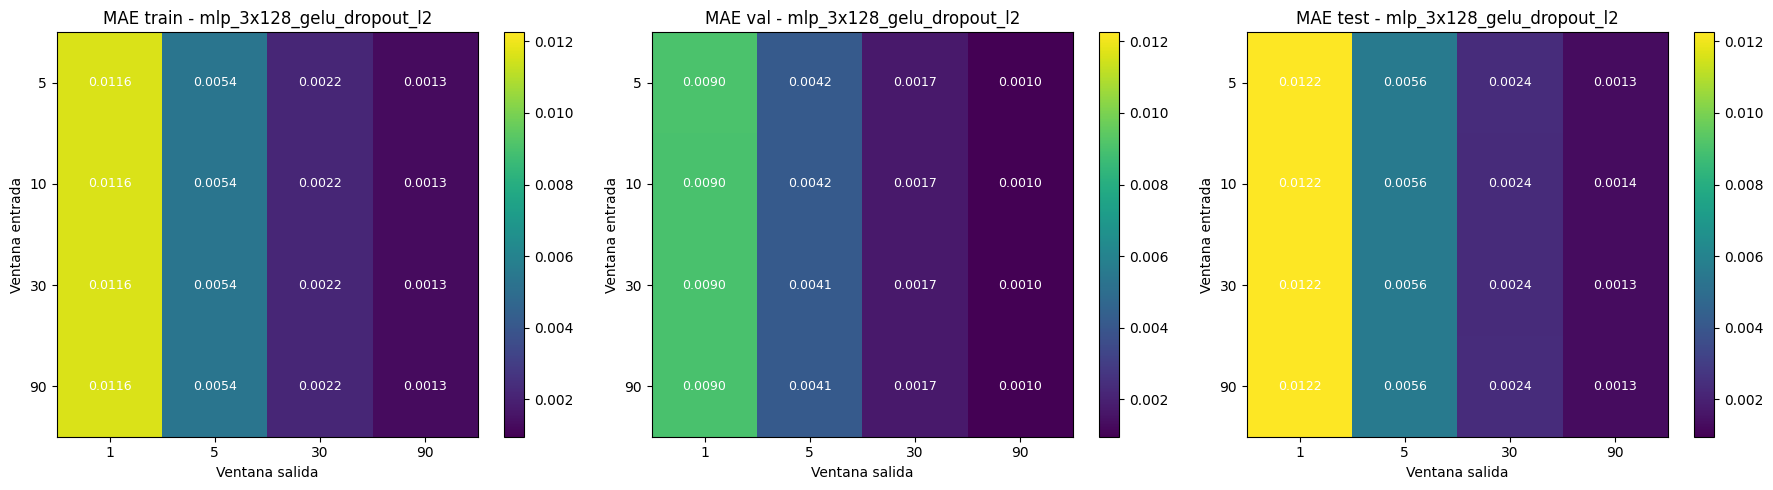

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
matrices = [
    (mae_train_matrix, "MAE train"),
    (mae_val_matrix, "MAE val"),
    (mae_test_matrix, "MAE test"),
]
vmin = min(matrix.values.min() for matrix, _ in matrices)
vmax = max(matrix.values.max() for matrix, _ in matrices)

for ax, (matrix, title) in zip(axes, matrices):
    im = ax.imshow(matrix.values, cmap="viridis", aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns)
    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index)
    ax.set_xlabel("Ventana salida")
    ax.set_ylabel("Ventana entrada")
    ax.set_title(f"{title} - {MODEL_NAME}")
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, f"{matrix.values[i, j]:.4f}", ha="center", va="center", color="white", fontsize=9)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

## Curvas de aprendizaje

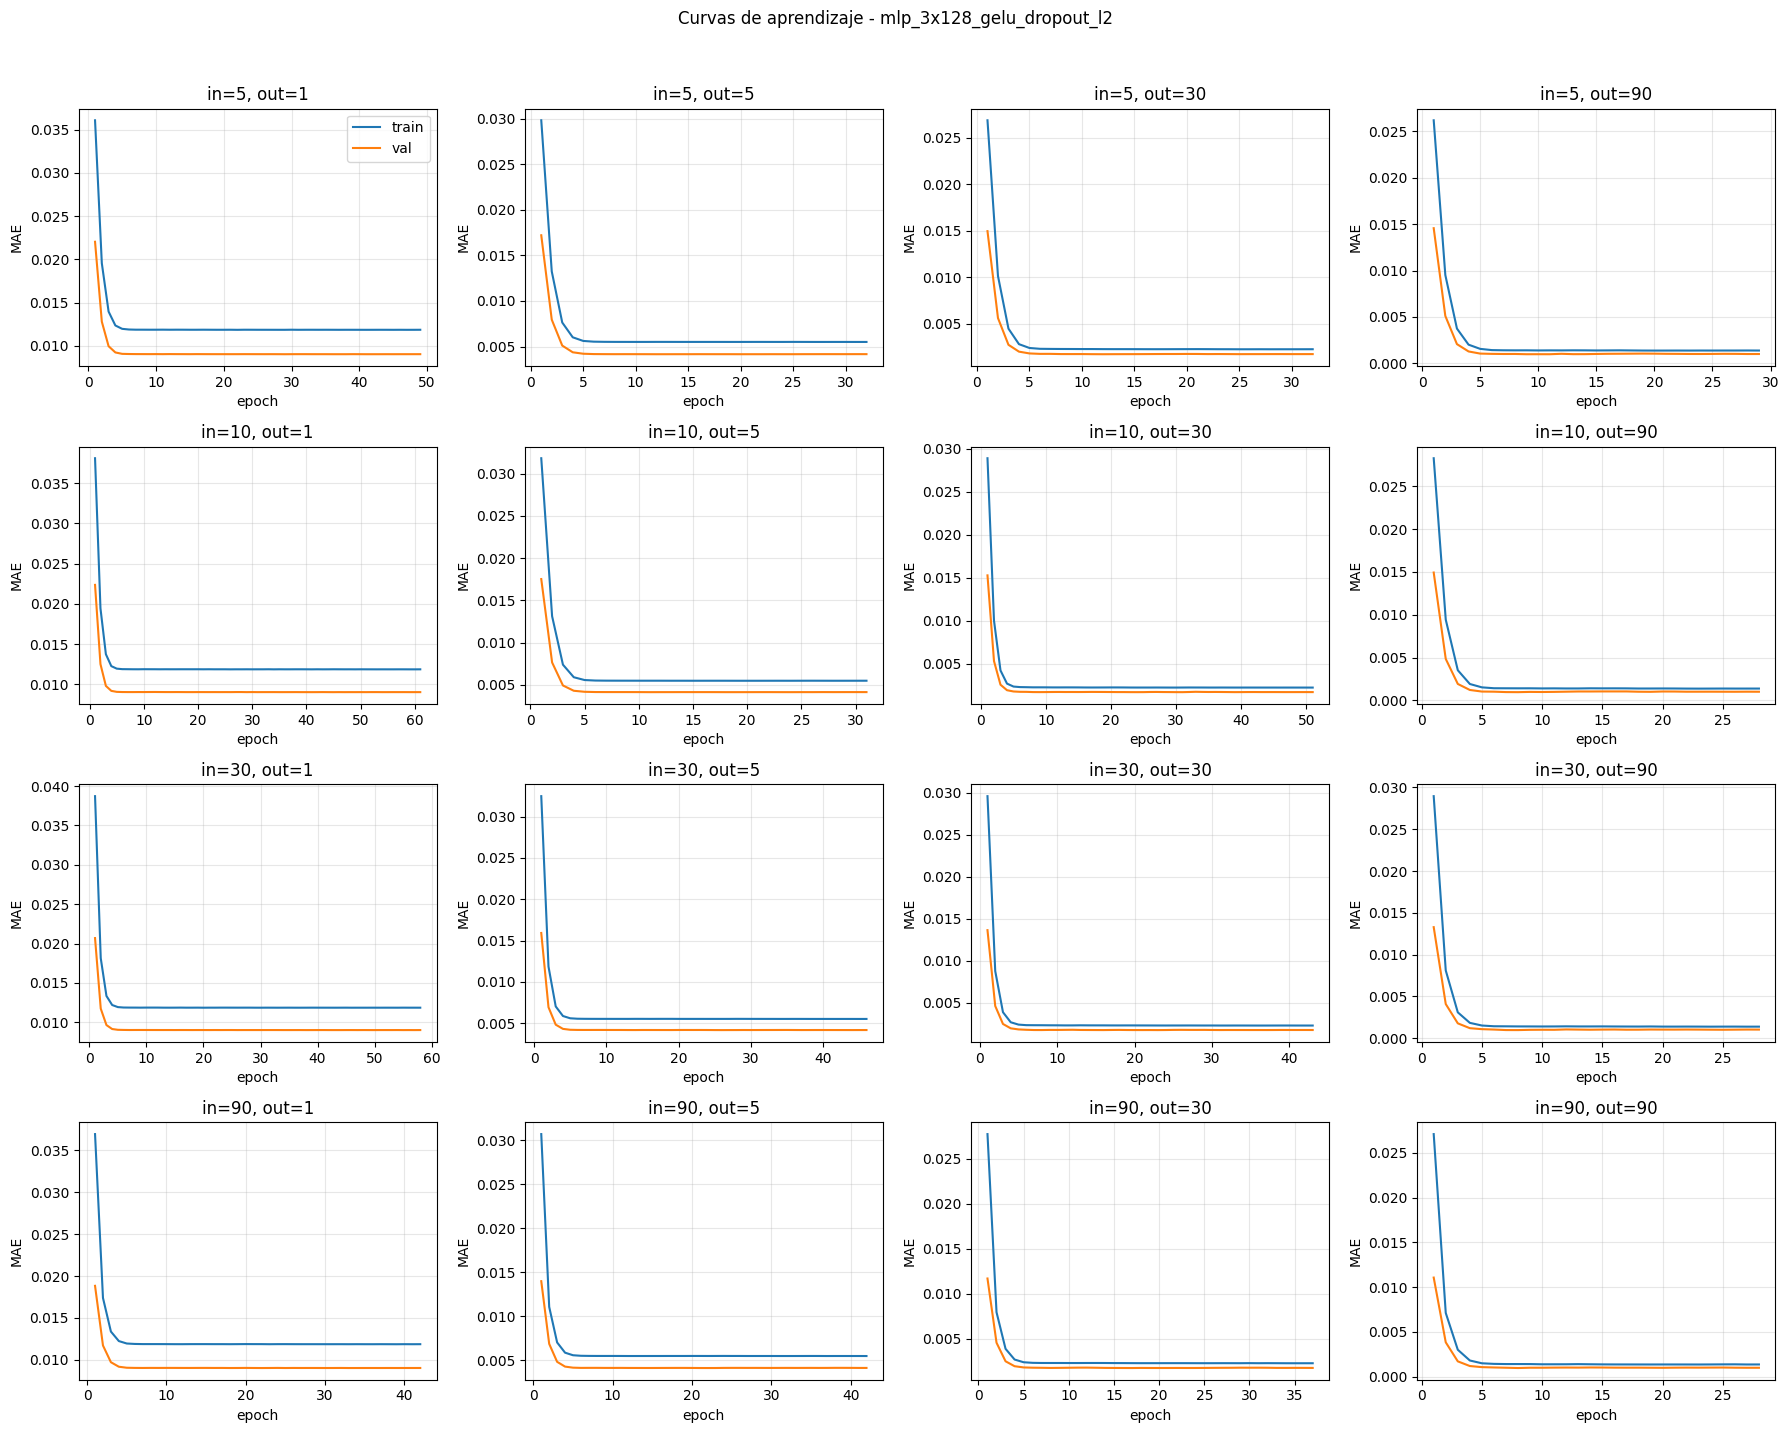

In [7]:
fig, axes = plt.subplots(4, 4, figsize=(18, 14), sharey=False)
axes = axes.ravel()

for ax, ((in_w, out_w), group) in zip(
    axes,
    history_df.groupby(["input_window", "output_window"], sort=True),
):
    ax.plot(group["epoch"], group["loss"], label="train")
    ax.plot(group["epoch"], group["val_loss"], label="val")
    ax.set_title(f"in={in_w}, out={out_w}")
    ax.set_xlabel("epoch")
    ax.set_ylabel("MAE")
    ax.grid(True, alpha=0.3)

axes[0].legend()
plt.suptitle(f"Curvas de aprendizaje - {MODEL_NAME}", y=1.02)
plt.tight_layout()
plt.show()

## Comparacion contra regresion lineal

,input_window,output_window,MAE_test,MAE_test_benchmark,delta,pct_delta
0,5,1,0.012230,0.012384,-0.000154,-1.242151
1,5,5,0.005583,0.005625,-0.000042,-0.748371
2,5,30,0.002371,0.002340,0.000031,1.313537
3,5,90,0.001343,0.001271,0.000071,5.598164
4,10,1,0.012228,0.012554,-0.000326,-2.600145
5,10,5,0.005582,0.005698,-0.000115,-2.024703
6,10,30,0.002366,0.002358,0.000008,0.326576
7,10,90,0.001351,0.001282,0.000069,5.379388
8,30,1,0.012233,0.012924,-0.000691,-5.349359
9,30,5,0.005598,0.005877,-0.000279,-4.750374


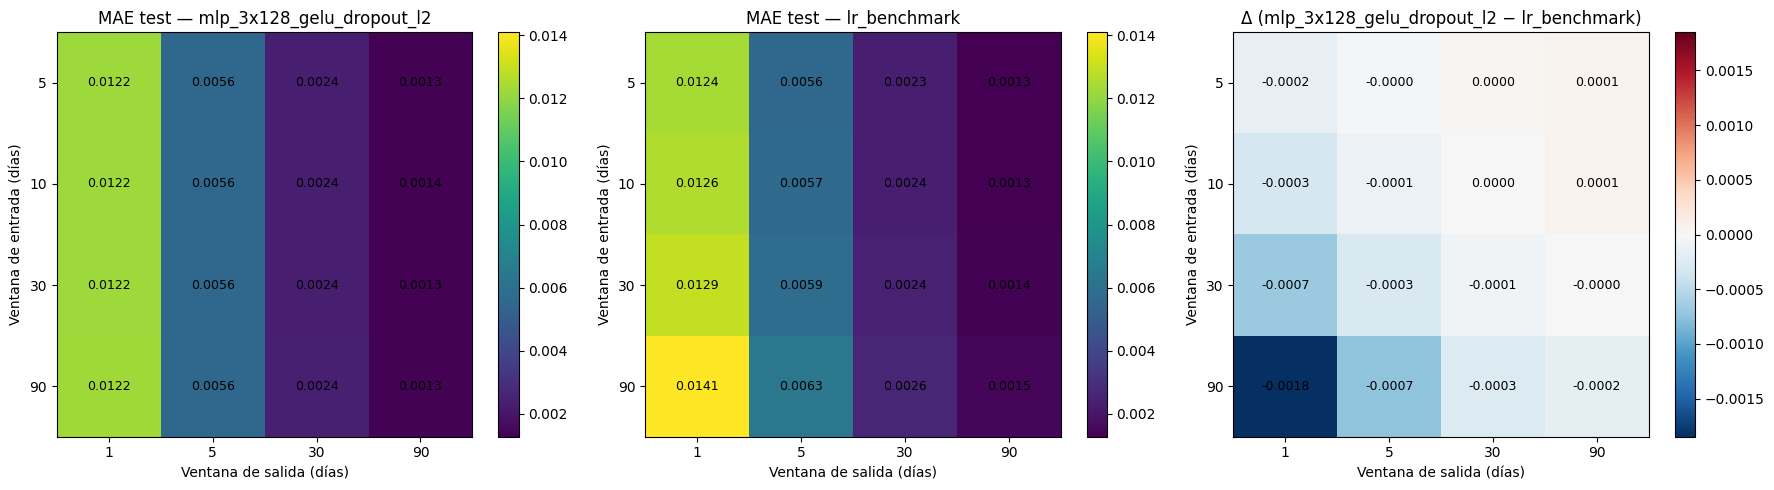

In [8]:
comparison = compare_to_benchmark(results_df, benchmark="lr_benchmark")
display(comparison)

plot_benchmark_comparison(results_df, benchmark="lr_benchmark", model_name=MODEL_NAME)
plt.show()